#Features Vector

In [108]:
from pyspark.ml.feature import VectorAssembler
feature_cols = [
    "Age", "Income", "LoanAmount", "Credit_Score",
    "Employment_Years", "Credit_History", "Has_Defaulted",
    "Dependents"
]
categorical_cols = ["Gender", "Education_Level", "Married", "Job_Type", "Property_Area"]

for col in categorical_cols:
    if col not in df.columns:
        print(f"Warning: {col} not found")
all_features = feature_cols + categorical_cols

assembler = VectorAssembler(
    inputCols=all_features,
    outputCol="features",
    handleInvalid="skip"
)

df = assembler.transform(df)

df = df.withColumnRenamed("Loan_Status", "label")

df = df.dropna()

print(" Features ready")
print(f"Total rows: {df.count()}")

 Features ready
Total rows: 1008883


#Split

In [63]:
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)
print(f"Training data: {train_df.count()} rows")
print(f"Testing data: {test_df.count()} rows")

Training data: 806927 rows
Testing data: 201956 rows


#Random Forest

In [72]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(featuresCol="features",labelCol="label",predictionCol="prediction",probabilityCol="probability",
    numTrees=200,
    maxDepth=15,
    minInstancesPerNode=10,
    minInfoGain=0.01,
    impurity="gini",
    subsamplingRate=0.8,
    seed=42,
    cacheNodeIds=True,
    maxBins=32 )
print(" Random Forest model defined")
print(f"Number of trees: {rf.getNumTrees}")
print(f"Max depth: {rf.getMaxDepth()}")

 Random Forest model defined
Number of trees: <bound method _RandomForestParams.getNumTrees of RandomForestClassifier_a6bb81d672fb>
Max depth: 15


#Training

In [73]:
print("Training Random Forest...")
rf_model = rf.fit(train_df)
print( "Training complete!")

Training Random Forest...
Training complete!


#Prediction

In [125]:
rf_predictions = rf_model.transform(test_df)
print("Predictions complete")
rf_predictions.select("label", "prediction", "probability").show(10)

Predictions complete
+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|    0|       0.0|[0.85437090788198...|
|    0|       0.0|[0.82670615855619...|
|    0|       0.0|[0.85437090788198...|
|    1|       0.0|[0.82187462673253...|
|    0|       0.0|[0.85437090788198...|
|    0|       0.0|[0.84103037189139...|
|    0|       0.0|[0.85437090788198...|
|    0|       0.0|[0.84607896549315...|
|    0|       0.0|[0.84607896549315...|
|    0|       0.0|[0.76583694929886...|
+-----+----------+--------------------+
only showing top 10 rows


#Evaluation

In [119]:
#Accuracy
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
acc_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)
accuracy = acc_eval.evaluate(rf_predictions)

In [120]:
# F1 Score
f1_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)
f1 = f1_eval.evaluate(rf_predictions)

In [121]:
#Precision & Recall
precision = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="precisionByLabel", metricLabel=1.0
).evaluate(rf_predictions)

recall = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="recallByLabel", metricLabel=1.0
).evaluate(rf_predictions)

In [122]:
#AUC
from pyspark.ml.evaluation import BinaryClassificationEvaluator
auc_eval = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)
auc = auc_eval.evaluate(rf_predictions)

In [123]:
print(f" Accuracy:   {accuracy:.4f}")
print(f" F1 Score:   {f1:.4f}")
print(f"AUC:        {auc:.4f}")
print(f"Precision:  {precision:.4f}")
print(f" Recall:     {recall:.4f}")



 Accuracy:   0.7924
 F1 Score:   0.7868
AUC:        0.8655
Precision:  0.7862
 Recall:     0.8991


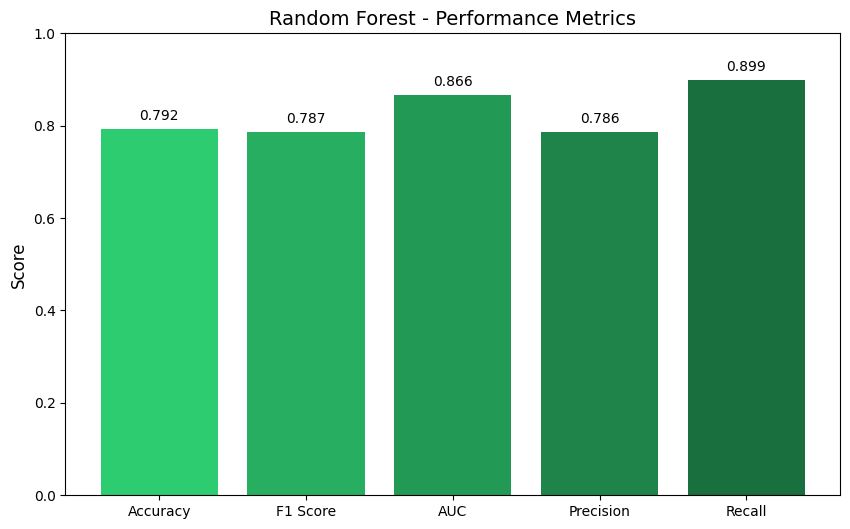

In [124]:
metrics = ['Accuracy', 'F1 Score', 'AUC', 'Precision', 'Recall']
scores = [accuracy, f1, auc, precision, recall]
colors = ['#2ecc71', '#27ae60', '#229954', '#1e8449', '#196f3d']

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, scores, color=colors)
plt.ylim(0, 1)
plt.ylabel('Score', fontsize=12)
plt.title('Random Forest - Performance Metrics', fontsize=14)
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{score:.3f}', ha='center', fontsize=10)

plt.show()

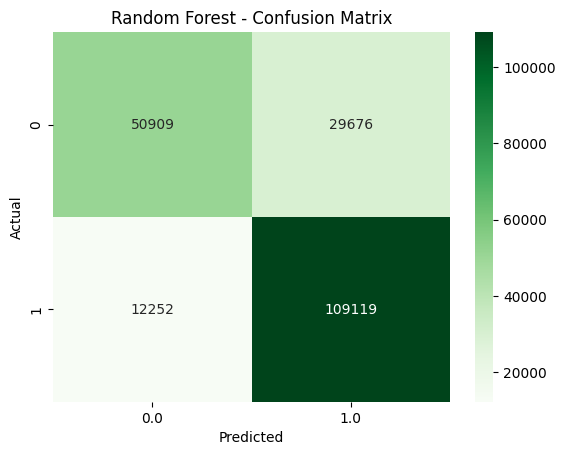

In [117]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

rf_pred_pd = rf_predictions.select("label", "prediction").toPandas()
rf_cm = pd.crosstab(rf_pred_pd["label"], rf_pred_pd["prediction"])
sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

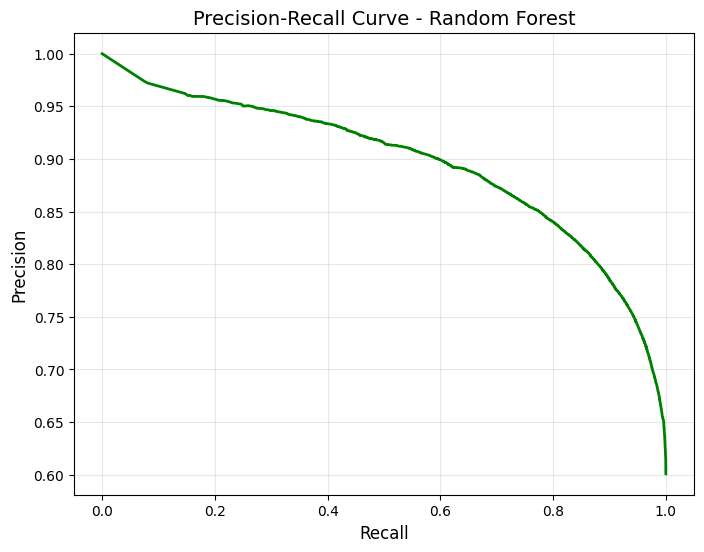

In [116]:
from sklearn.metrics import precision_recall_curve

y_true = pred_pd["label"]
y_scores = pred_pd["probability"].apply(lambda x: float(x[1]))

precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_scores)

plt.figure(figsize=(8, 6))
plt.plot(recall_curve, precision_curve, 'g-', linewidth=2)
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Precision-Recall Curve - Random Forest", fontsize=14)
plt.grid(alpha=0.3)
plt.show()

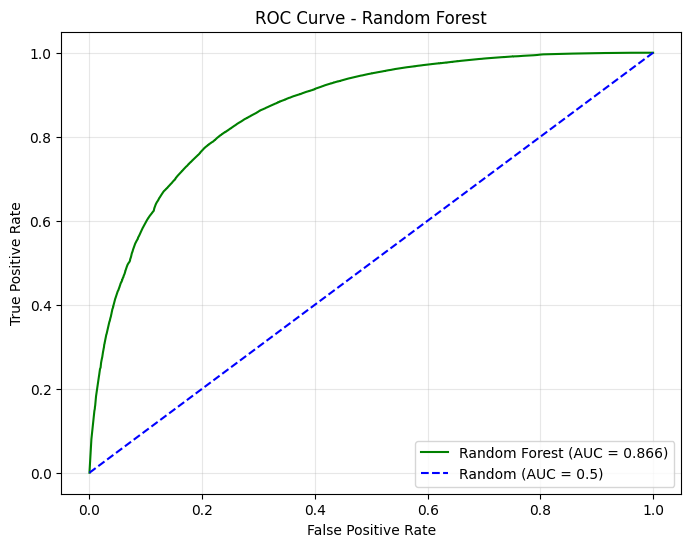

In [115]:
from sklearn.metrics import roc_curve, auc

pred_pd = rf_predictions.select("label", "probability").toPandas()
y_true = pred_pd["label"]
y_score = pred_pd["probability"].apply(lambda x: float(x[1]))

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'g-', label=f'Random Forest (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'b--', label='Random (AUC = 0.5)')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [114]:
rf_importance = rf_model.featureImportances

feature_names = [
    "Age", "Income", "LoanAmount", "Credit_Score",
    "Employment_Years", "Credit_History", "Has_Defaulted",
    "Dependents", "Gender", "Education_Level",
    "Married", "Job_Type", "Property_Area"
]

print("\nRandom Forest Feature Importances:")
for name, imp in zip(feature_names, rf_importance):
    print(f"{name:20}: {imp:.4f}")


Random Forest Feature Importances:
Age                 : 0.0102
Income              : 0.0834
LoanAmount          : 0.0024
Credit_Score        : 0.1726
Employment_Years    : 0.0591
Credit_History      : 0.3247
Has_Defaulted       : 0.1303
Dependents          : 0.0001
Gender              : 0.0000
Education_Level     : 0.0074
Married             : 0.0000
Job_Type            : 0.2096
Property_Area       : 0.0001


/tmp/ipykernel_5707/3364802256.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=fi_df, palette="viridis")


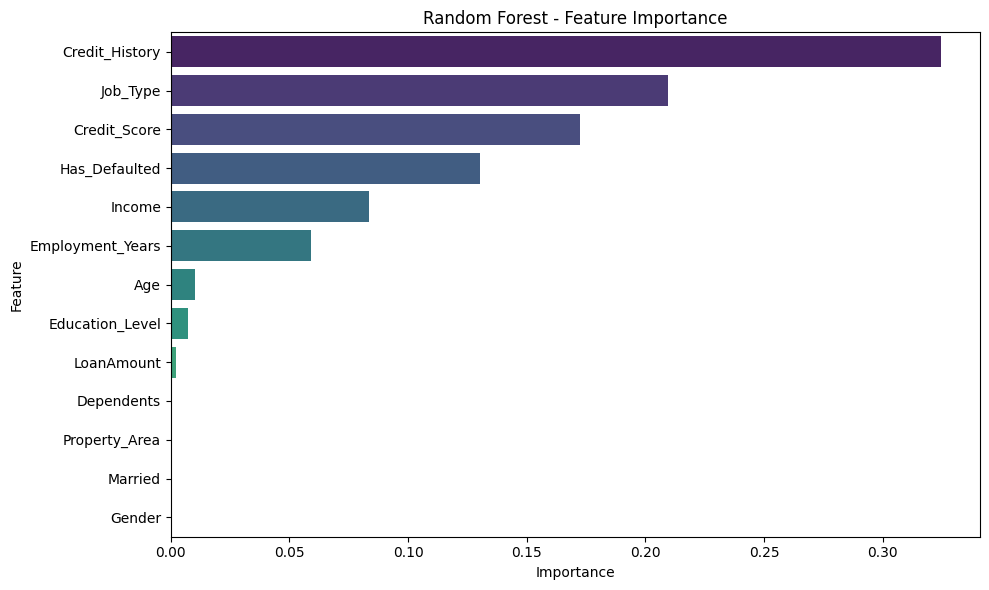

In [113]:
rf_importance = rf_model.featureImportances.toArray()
fi_df = pd.DataFrame({"Feature": feature_names, "Importance": rf_importance})
fi_df = fi_df.sort_values("Importance", ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=fi_df, palette="viridis")
plt.title("Random Forest - Feature Importance")
plt.tight_layout()
plt.show()

In [112]:
# Save the best model
import joblib
# Save Random Forest
rf_model.save("random_forest_model")
# Save as pickle (for later use)
# joblib.dump(rf_model, "random_forest_model.pkl")